# **Pavan S - 24BAD085**

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

## Loading the Dataset

In [ ]:
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")
print("Dataset downloaded to:", path)
os.listdir(path)

100%|██████████| 8.70k/8.70k [00:00<00:00, 14.6MB/s]

Extracting files...
Dataset downloaded to: /root/.cache/kagglehub/datasets/spscientist/students-performance-in-exams/versions/1


['StudentsPerformance.csv']

In [ ]:
df = pd.read_csv(os.path.join(path, "StudentsPerformance.csv"))
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## Target Variable Construction

In [ ]:
df["final_score"] = df[["math score", "reading score", "writing score"]].mean(axis=1)

## Encoding Categorical Features

In [ ]:
le = LabelEncoder()

df["parent_education"] = le.fit_transform(df["parental level of education"])
df["test_prep"] = le.fit_transform(df["test preparation course"])

## Feature Selection

In [ ]:
X = df[["parent_education", "test_prep"]]
y = df["final_score"]

## Missing Value Handling

In [ ]:
X.isnull().sum()

,0
parent_education,0
test_prep,0


## Feature Scaling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## Multilinear Regression Model

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

## Model Evaluation

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print({
    "MSE": mse,
    "RMSE": rmse,
    "R2": r2
})



{'MSE': 207.91715060774996, 'RMSE': np.float64(14.419332529897144), 'R2': 0.030085923188504338}


## Coefficient Interpretation

In [ ]:
co_df = pd.DataFrame({
    "Feature": ["Parental Education", "Test Preparation"],
    "Coefficient": lr.coef_
})
co_df

,Feature,Coefficient
0,Parental Education,-1.006718
1,Test Preparation,-3.840039


## Ridge and Lasso Regularization

In [ ]:
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.01)

ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso"],
    "RMSE": [
        rmse,
        np.sqrt(mean_squared_error(y_test, ridge.predict(X_test))),
        np.sqrt(mean_squared_error(y_test, lasso.predict(X_test)))
    ],
    "R2": [
        r2,
        r2_score(y_test, ridge.predict(X_test)),
        r2_score(y_test, lasso.predict(X_test))
    ]
})

,Model,RMSE,R2
0,Linear,14.419333,0.030086
1,Ridge,14.419139,0.030112
2,Lasso,14.419504,0.030063


## Predicted vs Actual Scores

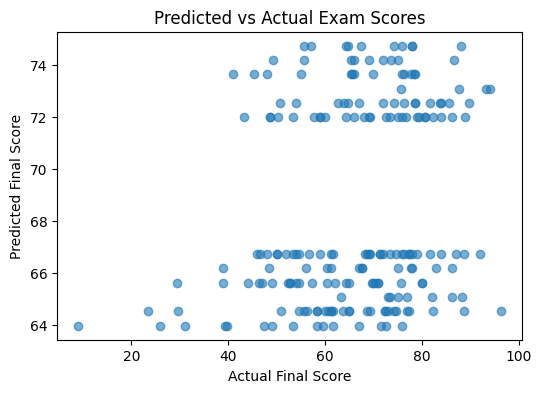

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Predicted vs Actual Exam Scores")
plt.show()

## Coefficient Magnitude

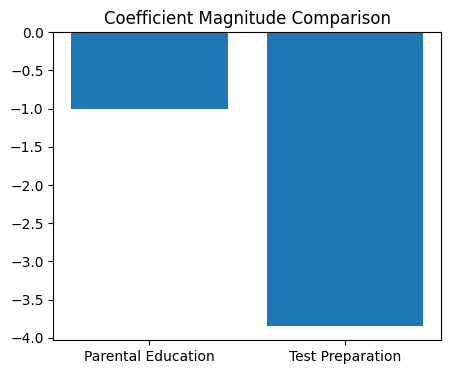

In [ ]:
plt.figure(figsize=(5,4))
plt.bar(co_df["Feature"], co_df["Coefficient"])
plt.title("Coefficient Magnitude Comparison")
plt.show()

## Residual Distribution

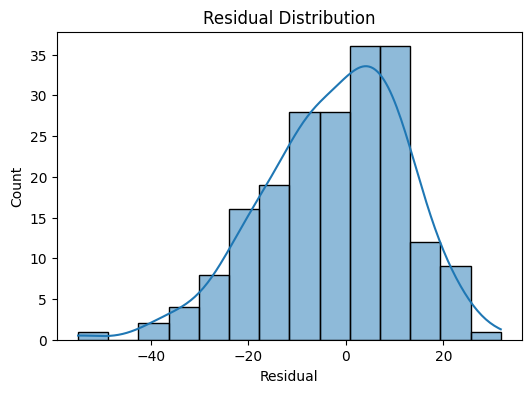

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.xlabel("Residual")
plt.title("Residual Distribution")
plt.show()